<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  8.30MB/s    in 33s     
2026-09-30 15:55:14 (6.17 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


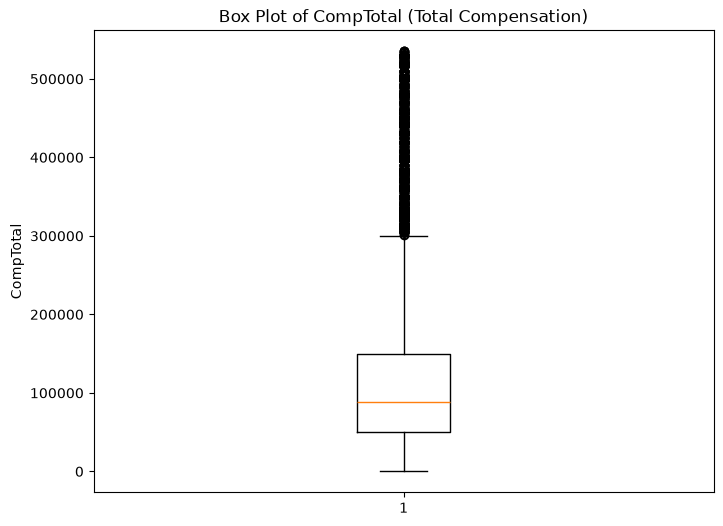

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

QUERY = "SELECT CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)

df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# Filtrar outliers (valores atípicos extremos) para que la gráfica sea legible
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['CompTotal'] >= (Q1 - 1.5 * IQR)) & (df['CompTotal'] <= (Q3 + 1.5 * IQR))]

plt.figure(figsize=(8, 6))
plt.boxplot(df_filtered['CompTotal'].dropna(), orientation='vertical')
plt.title('Box Plot of CompTotal (Total Compensation)')
plt.ylabel('CompTotal')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


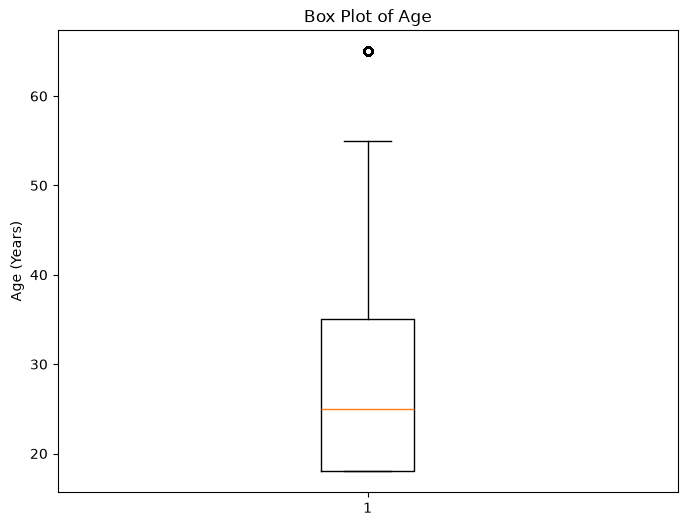

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

QUERY = "SELECT Age FROM main"
df = pd.read_sql_query(QUERY, conn)

# Convertir la columna Age a valores numéricos extrayendo los dígitos
df['Age_num'] = df['Age'].astype(str).str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(8, 6))
plt.boxplot(df['Age_num'].dropna(), orientation='vertical')
plt.title('Box Plot of Age')
plt.ylabel('Age (Years)')
plt.show()


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Figure size 1000x600 with 0 Axes>

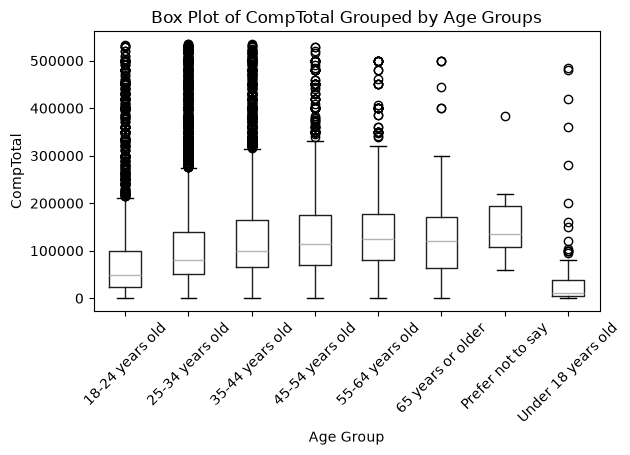

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

QUERY = "SELECT CompTotal, Age FROM main"
df = pd.read_sql_query(QUERY, conn)

df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# Filtrar outliers para una visualización clara
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['CompTotal'] >= (Q1 - 1.5 * IQR)) & (df['CompTotal'] <= (Q3 + 1.5 * IQR))]

plt.figure(figsize=(10, 6))
df_filtered.boxplot(column='CompTotal', by='Age', grid=False, rot=45)
plt.title('Box Plot of CompTotal Grouped by Age Groups')
plt.suptitle('')  # Quitar el subtítulo por defecto de pandas
plt.xlabel('Age Group')
plt.ylabel('CompTotal')
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


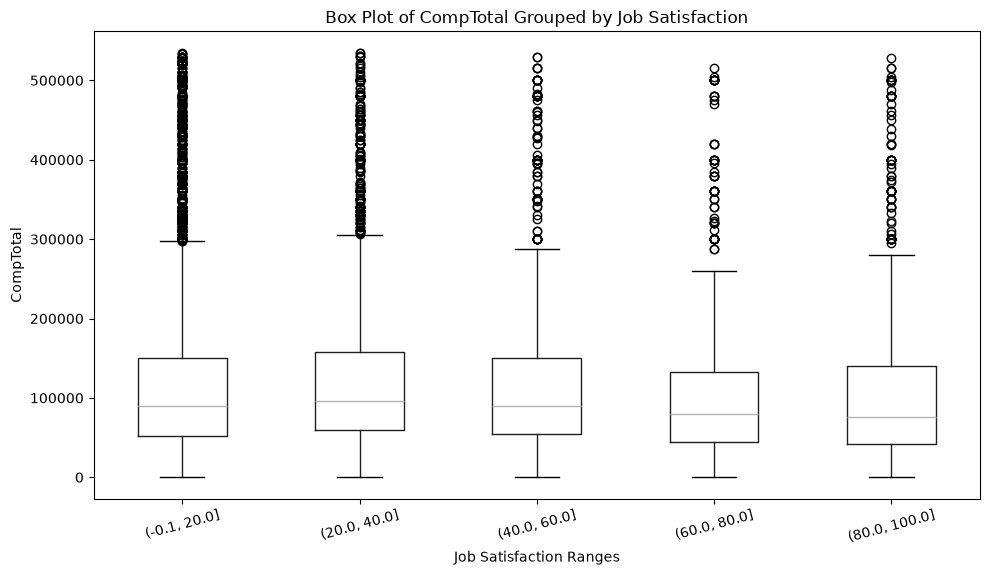

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

QUERY = "SELECT CompTotal, JobSatPoints_6 FROM main"
df = pd.read_sql_query(QUERY, conn)

df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# Convertir JobSatPoints_6 a valores numéricos
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Agrupar JobSatPoints_6 en rangos/categorías para simplificar el eje X
df['JobSatGroup'] = pd.cut(df['JobSatPoints_6'], bins=5)

# Filtrar valores atípicos (outliers) de CompTotal para limpiar el gráfico
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['CompTotal'] >= (Q1 - 1.5 * IQR)) & (df['CompTotal'] <= (Q3 + 1.5 * IQR))]

# Crear la figura especificando los ejes correctamente
fig, ax = plt.subplots(figsize=(10, 6))
df_filtered.boxplot(column='CompTotal', by='JobSatGroup', ax=ax, grid=False)

plt.title('Box Plot of CompTotal Grouped by Job Satisfaction')
plt.suptitle('')  # Quitar el título secundario por defecto
plt.xlabel('Job Satisfaction Ranges')
plt.ylabel('CompTotal')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


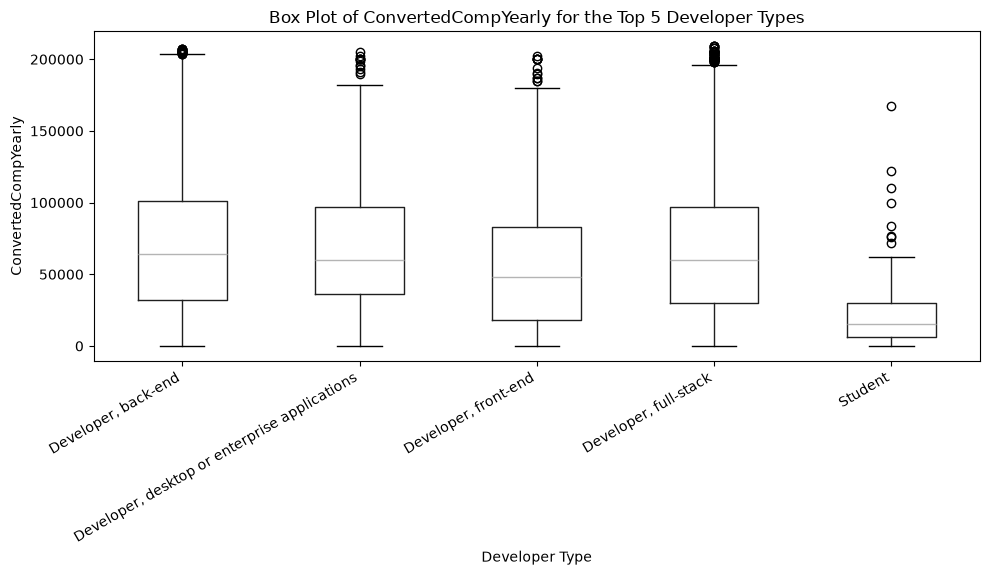

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Leer los datos desde la tabla main
QUERY = "SELECT ConvertedCompYearly, DevType FROM main"
df = pd.read_sql_query(QUERY, conn)

df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# 2. Separar los tipos de desarrollador y obtener los Top 5
dev_series = df['DevType'].dropna().astype(str).str.split(';').explode()
top5_devs = dev_series.value_counts().head(5).index.tolist()

# 3. Filtrar los datos para incluir únicamente el Top 5
df_dev = df.dropna(subset=['DevType']).copy()
df_dev['DevType_split'] = df_dev['DevType'].astype(str).str.split(';')
df_exploded = df_dev.explode('DevType_split')
df_top5 = df_exploded[df_exploded['DevType_split'].isin(top5_devs)]

# 4. Filtrar outliers para limpiar la gráfica
Q1 = df_top5['ConvertedCompYearly'].quantile(0.25)
Q3 = df_top5['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1
df_top5_filtered = df_top5[(df_top5['ConvertedCompYearly'] >= (Q1 - 1.5 * IQR)) & (df_top5['ConvertedCompYearly'] <= (Q3 + 1.5 * IQR))]

# 5. Generar la gráfica
fig, ax = plt.subplots(figsize=(10, 6))
df_top5_filtered.boxplot(column='ConvertedCompYearly', by='DevType_split', ax=ax, grid=False)

plt.title('Box Plot of ConvertedCompYearly for the Top 5 Developer Types')
plt.suptitle('')
plt.xlabel('Developer Type')
plt.ylabel('ConvertedCompYearly')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


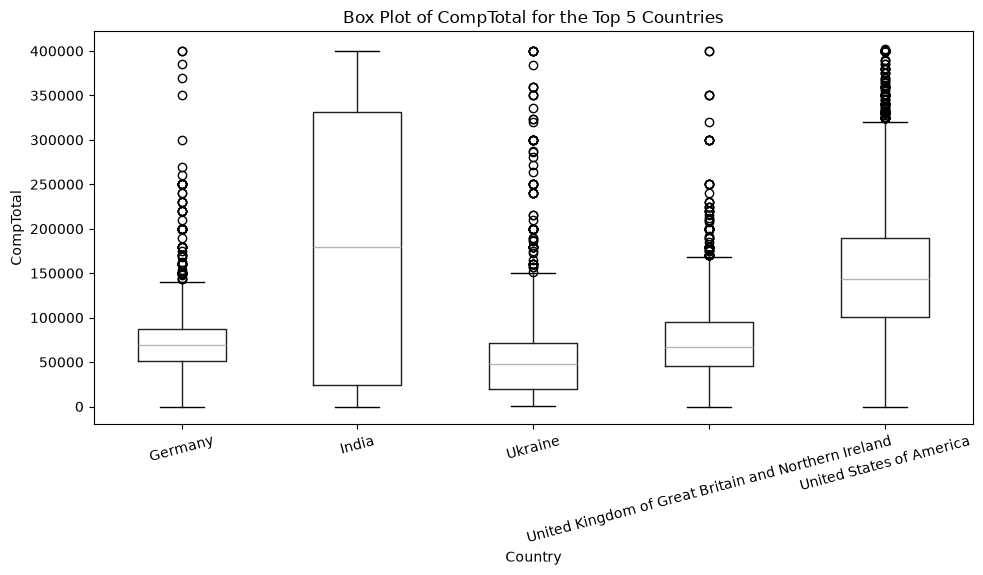

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Leer los datos desde la tabla main
QUERY = "SELECT CompTotal, Country FROM main"
df = pd.read_sql_query(QUERY, conn)

df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# 2. Obtener los Top 5 países con más encuestados
top5_countries = df['Country'].value_counts().head(5).index.tolist()

# 3. Filtrar para los Top 5 países
df_top5_countries = df[df['Country'].isin(top5_countries)].copy()

# 4. Filtrar outliers para que la caja sea clara
Q1 = df_top5_countries['CompTotal'].quantile(0.25)
Q3 = df_top5_countries['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df_top5_countries[(df_top5_countries['CompTotal'] >= (Q1 - 1.5 * IQR)) & (df_top5_countries['CompTotal'] <= (Q3 + 1.5 * IQR))]

# 5. Generar la gráfica
fig, ax = plt.subplots(figsize=(10, 6))
df_filtered.boxplot(column='CompTotal', by='Country', ax=ax, grid=False)

plt.title('Box Plot of CompTotal for the Top 5 Countries')
plt.suptitle('')
plt.xlabel('Country')
plt.ylabel('CompTotal')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


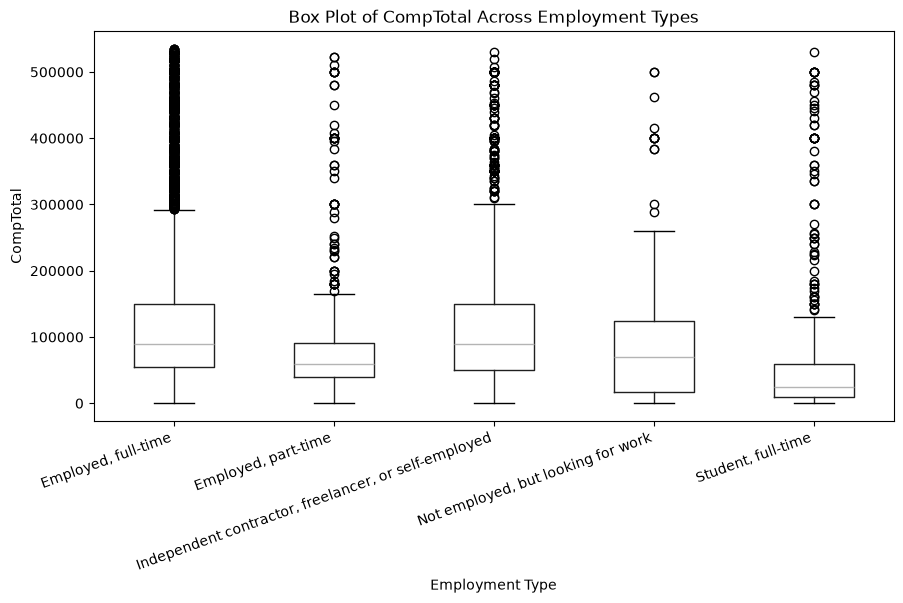

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar los datos desde la tabla main
QUERY = "SELECT CompTotal, Employment FROM main"
df = pd.read_sql_query(QUERY, conn)

df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# 2. Simplificar las etiquetas de Employment (tomar solo la primera categoría si hay varias combinadas)
df['Employment_Clean'] = df['Employment'].dropna().astype(str).str.split(';').str[0]

# 3. Filtrar para mostrar únicamente los Top 5 tipos de empleo más representativos
top5_employment = df['Employment_Clean'].value_counts().head(5).index.tolist()
df_top = df[df['Employment_Clean'].isin(top5_employment)].copy()

# 4. Filtrar valores atípicos (outliers) de CompTotal para una escala razonable
Q1 = df_top['CompTotal'].quantile(0.25)
Q3 = df_top['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df_top[(df_top['CompTotal'] >= (Q1 - 1.5 * IQR)) & (df_top['CompTotal'] <= (Q3 + 1.5 * IQR))]

# 5. Dibujar el boxplot perfectamente ordenado
fig, ax = plt.subplots(figsize=(10, 6))
df_filtered.boxplot(column='CompTotal', by='Employment_Clean', ax=ax, grid=False)

plt.title('Box Plot of CompTotal Across Employment Types')
plt.suptitle('')  # Quitar título automático repetido
plt.xlabel('Employment Type')
plt.ylabel('CompTotal')

# Ajustar rotación y posición de las etiquetas
plt.xticks(rotation=20, ha='right')
plt.gcf().subplots_adjust(bottom=0.25)

plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


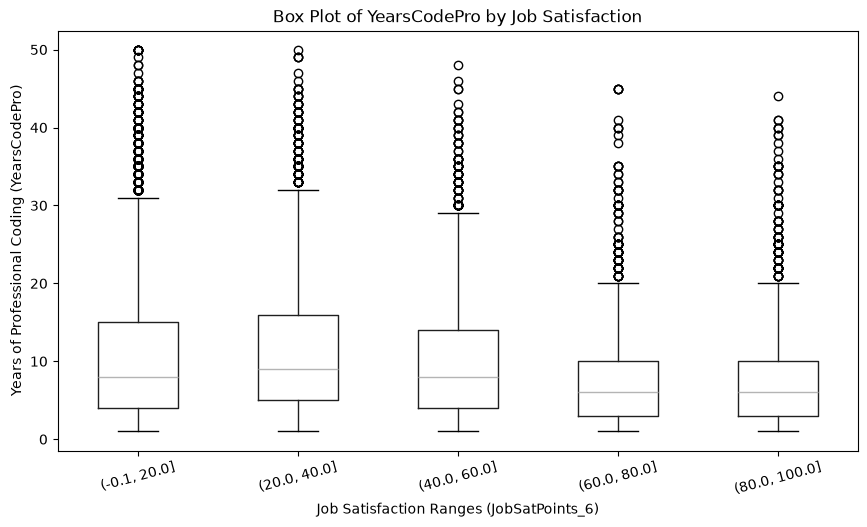

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar las columnas necesarias desde la tabla main
QUERY = "SELECT YearsCodePro, JobSatPoints_6 FROM main"
df = pd.read_sql_query(QUERY, conn)

# 2. Convertir YearsCodePro a formato numérico (limpiando textos si los hay)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# 3. Convertir JobSatPoints_6 a numérico y agrupas en rangos limpios para evitar amontonamiento
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['JobSatGroup'] = pd.cut(df['JobSatPoints_6'], bins=5)

# 4. Generar la gráfica sin advertencias
fig, ax = plt.subplots(figsize=(10, 6))
df.dropna(subset=['YearsCodePro', 'JobSatGroup']).boxplot(column='YearsCodePro', by='JobSatGroup', ax=ax, grid=False)

plt.title('Box Plot of YearsCodePro by Job Satisfaction')
plt.suptitle('')  # Quitar título automático repetido
plt.xlabel('Job Satisfaction Ranges (JobSatPoints_6)')
plt.ylabel('Years of Professional Coding (YearsCodePro)')
plt.xticks(rotation=15)
plt.gcf().subplots_adjust(bottom=0.2)

plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [20]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
